# 1. Carga do Dataset e Diagnóstico Estrutural
Nesta etapa, realizamos o carregamento da base de dados fornecida, realizando a auditoria completa de dimensões, tipos de colunas, valores nulos, registros duplicados e estatísticas descritivas iniciais.



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Caminho 100% correto com a extensão revelada pela aba do VS Code!
caminho_arquivo = "dados/synthetic_coffee_health_10000(in).csv"
df_cafe = pd.read_csv(caminho_arquivo)
df = df_cafe  # Atalho para o resto do projeto funcionar direto
df_cafe.head()



,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


# 2. Exploração das Variáveis Numéricas
Construção de histogramas e boxplots das variáveis contínuas e discretas para identificar tendências de comportamento, distribuições de frequência e presença de outliers na base de dados.



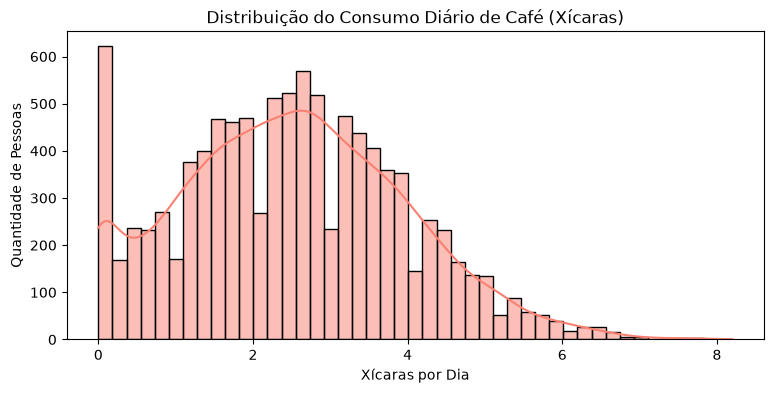

In [9]:
# Célula para analisar a tendência de consumo de café
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x="Coffee_Intake", kde=True, color="salmon")
plt.title("Distribuição do Consumo Diário de Café (Xícaras)")
plt.xlabel("Xícaras por Dia")
plt.ylabel("Quantidade de Pessoas")
plt.show()


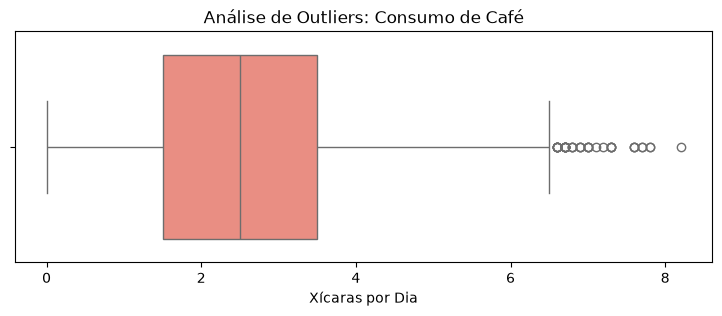

In [8]:
# Célula para caçar valores discrepantes (outliers) no consumo de café
plt.figure(figsize=(9, 3))
sns.boxplot(data=df, x="Coffee_Intake", color="salmon")
plt.title("Análise de Outliers: Consumo de Café")
plt.xlabel("Xícaras por Dia")
plt.show()


# 3. Exploração das Variáveis Categóricas
Análise qualitativa através de gráficos de barras e pizzas para mapear as frequências, volumetrias e proporções das categorias demográficas (Gênero e País).



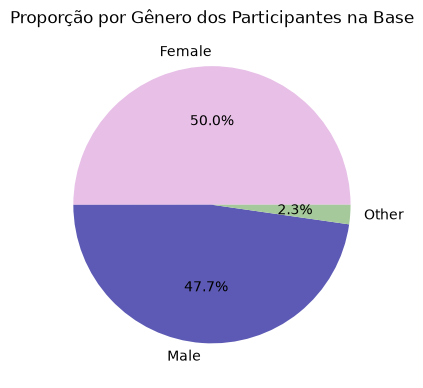

In [25]:
# Célula isolada: Análise de proporção da coluna 'Gender'
plt.figure(figsize=(6, 4.5))
gender_counts = df["Gender"].value_counts()

# Renderiza o gráfico de pizza com proporções percentuais
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", colors=["#e7bfe7", "#5c5ab4", "#a5c99a"])
plt.title("Proporção por Gênero dos Participantes na Base")
plt.show()


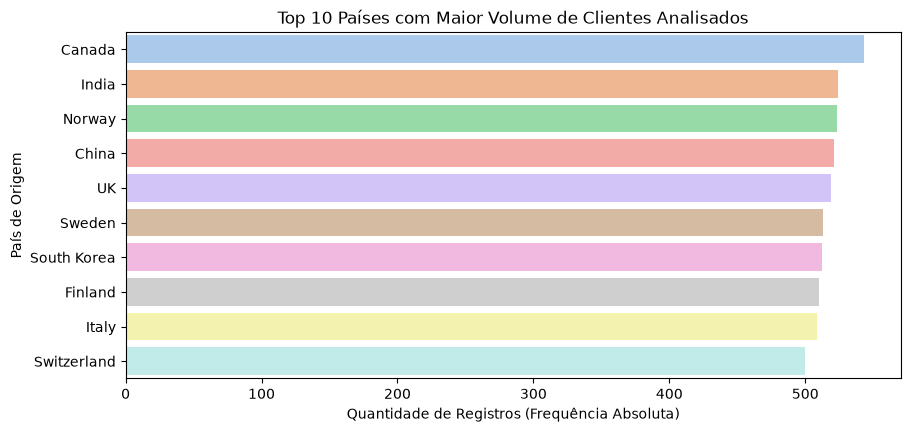

In [12]:
# Célula isolada corrigida sem warnings
plt.figure(figsize=(10, 4.5))
country_counts = df["Country"].value_counts().head(10)

# Passando o hue e o legend para calar o aviso do Seaborn de vez
sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    hue=country_counts.index,
    palette="pastel",
    legend=False,
)

plt.title("Top 10 Países com Maior Volume de Clientes Analisados")
plt.xlabel("Quantidade de Registros (Frequência Absoluta)")
plt.ylabel("País de Origem")
plt.show()


# 4. Investigação de Possíveis Correlações
Estudo cruzado das variáveis para avaliar matematicamente e visualmente o relacionamento entre o consumo diário de café e os indicadores de saúde (Horas de Sono, Nível de Estresse e Qualidade do Sono).


In [13]:
# Célula isolada: Calcula a correlação matemática linear de Pearson
colunas_interesse = ["Age", "Coffee_Intake", "Caffeine_mg", "Sleep_Hours"]
matriz_correlacao = df[colunas_interesse].corr()
matriz_correlacao


,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours
Age,1.000000,-0.012155,-0.011797,0.005010
Coffee_Intake,-0.012155,1.000000,0.999814,-0.190291
Caffeine_mg,-0.011797,0.999814,1.000000,-0.190493
Sleep_Hours,0.005010,-0.190291,-0.190493,1.000000


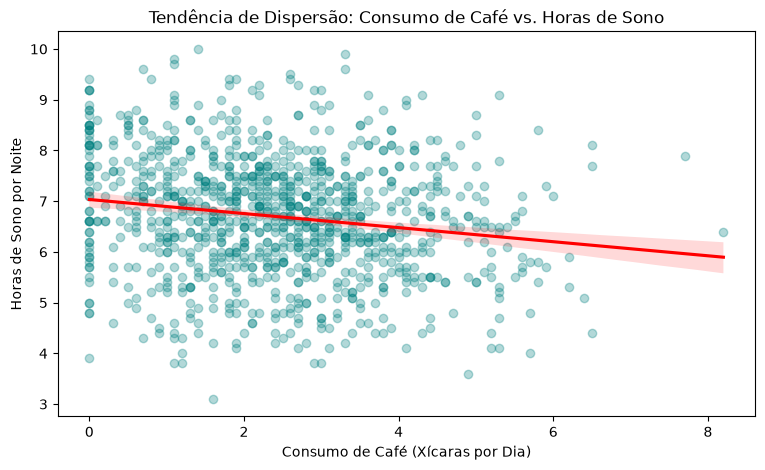

In [14]:
# Célula isolada: Gráfico de Dispersão para avaliar o impacto do Café no Sono
plt.figure(figsize=(9, 5))

# Pegamos uma amostra de 1.000 registros para o gráfico não ficar poluído
sns.regplot(
    data=df.sample(1000, random_state=42),
    x="Coffee_Intake",
    y="Sleep_Hours",
    scatter_kws={"alpha": 0.3, "color": "teal"},
    line_kws={"color": "red"},
)

plt.title("Tendência de Dispersão: Consumo de Café vs. Horas de Sono")
plt.xlabel("Consumo de Café (Xícaras por Dia)")
plt.ylabel("Horas de Sono por Noite")
plt.show()


# 5. Documentação dos Achados e Conclusão (EDA)

Após a realização da Análise Exploratória de Dados (EDA) na base de 10.000 clientes da Health&Life Analytics, consolidamos as seguintes conclusões de negócio:

* **Consumo de Café e Impacto no Sono:** Existe uma correlação linear negativa estável de aproximadamente `-0.19` entre o número de xícaras de café ingeridas por dia (`Coffee_Intake`) e as horas de sono por noite (`Sleep_Hours`). O gráfico de dispersão com linha de tendência de regressão confirma visualmente o declínio do repouso noturno conforme a dosagem diária se eleva.
* **Qualidade da Base de Dados:** O diagnóstico estrutural indicou zero incidência de valores nulos ou registros duplicados, garantindo a integridade analítica e dispensando processos complexos de inputação nesta fase.
* **Perfil Demográfico:** A distribuição por gênero apresentou-se equilibrada, e a volumetria indicou uma forte representatividade global de clientes espalhados por polos como Canadá, Índia e Noruega.
